In [1]:
# https://stackabuse.com/time-series-prediction-using-lstm-with-pytorch-in-python/
# OFICIAL: https://pytorch.org/tutorials/beginner/nlp/sequence_models_tutorial.html

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
%matplotlib inline

In [2]:
data = pd.read_csv('../data/df_clean.csv')
print(data.shape)
data.head()

(140592, 30)


,date,temperature_aeroparque,temperature_observatorio,temperature_openmeteo,relativehumidity_aeroparque,relativehumidity_observatorio,relativehumidity_openmeteo,pressure_aeroparque,pressure_observatorio,pressure_openmeteo,...,pm10_openmeteo,no2_centenario,no2_cordoba,no2_la_boca,no2_openmeteo,co_centenario,co_cordoba,co_la_boca,co_openmeteo,co_palermo
0,2009-10-01 00:00:00+00:00,NaN,NaN,11.0,NaN,NaN,81.0,NaN,NaN,1023.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-10-01 01:00:00+00:00,NaN,NaN,11.0,NaN,NaN,81.0,NaN,NaN,1023.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-10-01 02:00:00+00:00,NaN,NaN,10.8,NaN,NaN,82.0,NaN,NaN,1022.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-10-01 03:00:00+00:00,NaN,NaN,10.6,NaN,NaN,83.0,NaN,NaN,1021.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-10-01 04:00:00+00:00,NaN,NaN,10.7,NaN,NaN,79.0,NaN,NaN,1021.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


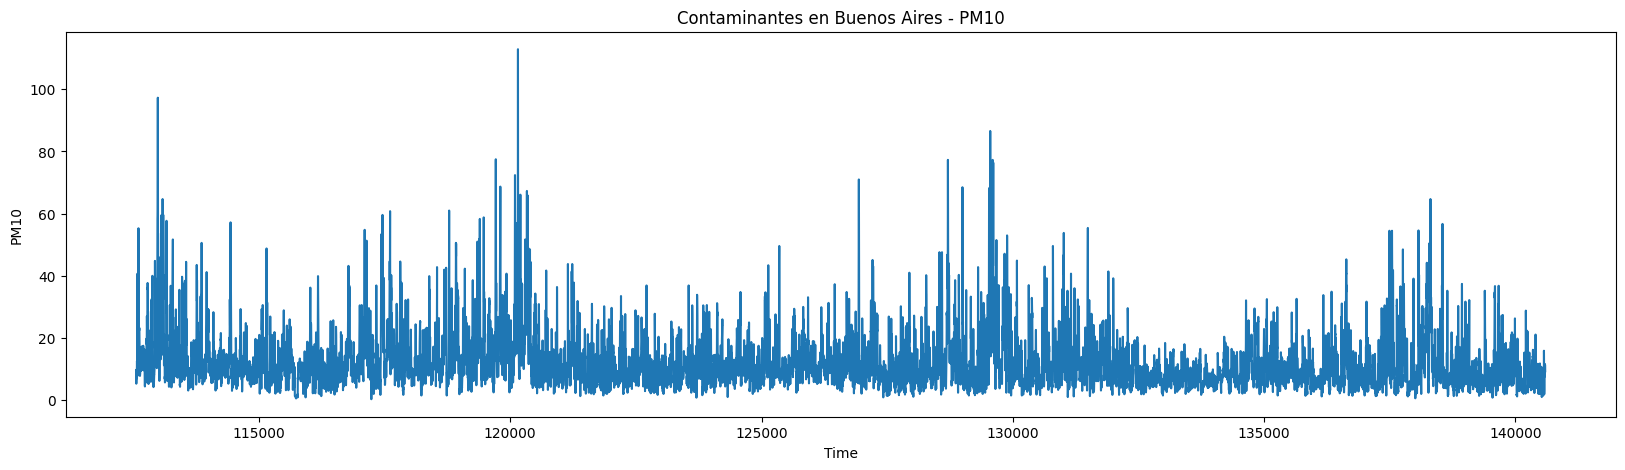

In [5]:
plt.figure(figsize = [20,5])
plt.plot(data.pm10_openmeteo)
plt.title("Contaminantes en Buenos Aires - PM10")
plt.xlabel("Time")
plt.ylabel("PM10")
plt.show()

In [6]:
train_percentage = 0.67
train_size = int(len(data)*train_percentage)

train = data["pm10_openmeteo"][:train_size].values.astype(float)
test = data["pm10_openmeteo"][train_size:].values.astype(float)

sc = MinMaxScaler(feature_range=(-1, 1))
train_norm = sc.fit_transform(train .reshape(-1, 1))

train_norm = torch.FloatTensor(train_norm).view(-1)

/home/bita/.pyenv/versions/medios_federales/lib/python3.10/site-packages/sklearn/utils/_array_api.py:686: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/home/bita/.pyenv/versions/medios_federales/lib/python3.10/site-packages/sklearn/utils/_array_api.py:706: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


In [7]:
np.shape(train_norm)

torch.Size([94196])

In [8]:
def create_input_output(input_data, window, ndays = 1):
    input_output = []
    data_size = len(input_data)
    for i in range(data_size - window - ndays):
        train_seq = input_data[i:i+window]
        train_label = input_data[i+window+ndays:i+window+ndays+1]
        input_output.append((train_seq ,train_label))
    return input_output
ndays = 10
window = 30
train_input_output = create_input_output(train_norm, window, ndays)
train_input_output[:2]

[(tensor([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
          nan, nan, nan, nan, nan, nan]),
  tensor([nan])),
 (tensor([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
          nan, nan, nan, nan, nan, nan]),
  tensor([nan]))]

In [9]:
# Documentation of pytorch Conv1D: https://pytorch.org/docs/stable/generated/torch.nn.Conv1d.html
class NN_conv(nn.Module):
    def __init__(self):
        super(NN_conv, self).__init__()
        self.conv1 = nn.Sequential(         
            nn.Conv1d(
                in_channels=1,             # Number of channels in the input image
                out_channels=5,            # Number of channels produced by the convolution
                kernel_size=5,             # Size of the convolving kernel 
                stride=1,                  # Stride of the convolution. Default: 1 
                padding=2,                 # Zero-padding added to both sides of the input. Default: 0 
            ),                              
            nn.ReLU(),                      
            nn.MaxPool1d(kernel_size=3),
        )
        self.conv2 = nn.Sequential(         
            nn.Conv1d(
                in_channels=5,             
                out_channels=8,             
                kernel_size=5,              
                stride=1,                   
                padding=2,                  
            ),                              
            nn.ReLU(),                      
            nn.MaxPool1d(kernel_size=2),    
            
        )
        self.out = nn.Linear(40, 1)  #output 3 classes: Cargo, Passenger or Fishing


    def forward(self, x):
        #print(x.size())
        x = self.conv1(x)
        #print(x.size())
        x = self.conv2(x)
        #print(x.size())
        x = x.view(-1, 8 * 5)
        #print(x.size())
        output = self.out(x)
        return output


net = NN_conv()

In [10]:
model = NN_conv()
loss_function = nn.MSELoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) #torch.optim.SGD(model.parameters(), lr=0.001)

In [ ]:
epochs = 100

for i in range(epochs):
    for inputs, labels in train_input_output:
        optimizer.zero_grad()
        inputs = inputs.view(1,1,window) # (N,C,L) N is a batch size, C denotes a number of channels, L is a length of signal sequence. https://pytorch.org/docs/stable/generated/torch.nn.Conv1d.html
        y_pred = model(inputs)

        single_loss = loss_function(y_pred, labels)
        single_loss.backward()
        optimizer.step()

    if i%10 == 1:
        print(f'epoch: {i:3} loss: {single_loss.item():10.8f}')

print(f'epoch: {i:3} loss: {single_loss.item():10.10f}')

/home/bita/.pyenv/versions/medios_federales/lib/python3.10/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [ ]:
test_norm = sc.transform(test.reshape(-1, 1))
test_norm = torch.FloatTensor(test_norm).view(-1)
test_input_output = create_input_output(test_norm, window, ndays)
test_input_output[:2]

[(tensor([-0.4829, -0.2928, -0.2548, -0.1863, -0.4068, -0.3004,  0.1407, -0.4068,
          -0.5970, -0.2776, -0.4221,  0.0646,  0.1331,  0.1331,  0.4601,  0.2928,
          -0.0114, -0.1483, -0.2776, -0.2167, -0.2928, -0.1407, -0.5057, -0.0875,
          -0.3688, -0.3384, -0.3384, -0.2243, -0.4753, -0.6274]),
  tensor([-0.2015])),
 (tensor([-0.2928, -0.2548, -0.1863, -0.4068, -0.3004,  0.1407, -0.4068, -0.5970,
          -0.2776, -0.4221,  0.0646,  0.1331,  0.1331,  0.4601,  0.2928, -0.0114,
          -0.1483, -0.2776, -0.2167, -0.2928, -0.1407, -0.5057, -0.0875, -0.3688,
          -0.3384, -0.3384, -0.2243, -0.4753, -0.6274, -0.2395]),
  tensor([-0.1331]))]

In [ ]:
y_pred_norm = []
for inputs, labels in test_input_output:
    with torch.no_grad():
        inputs = inputs.view(1,1,window)
        y_pred_norm.append(model(inputs).item())
y_pred_norm[:5]

[-0.13193349540233612,
 0.029398459941148758,
 0.026214342564344406,
 0.04802677407860756,
 0.004474818706512451]

In [ ]:
y_pred = sc.inverse_transform(np.array(y_pred_norm).reshape(-1, 1))
y_pred[:5]

array([[11.41507454],
       [13.53658975],
       [13.4947186 ],
       [13.78155208],
       [13.20884387]])

In [ ]:
y_true = test[window+ndays:]

In [ ]:
mean_squared_error(y_true, y_pred)

13.524712006584169

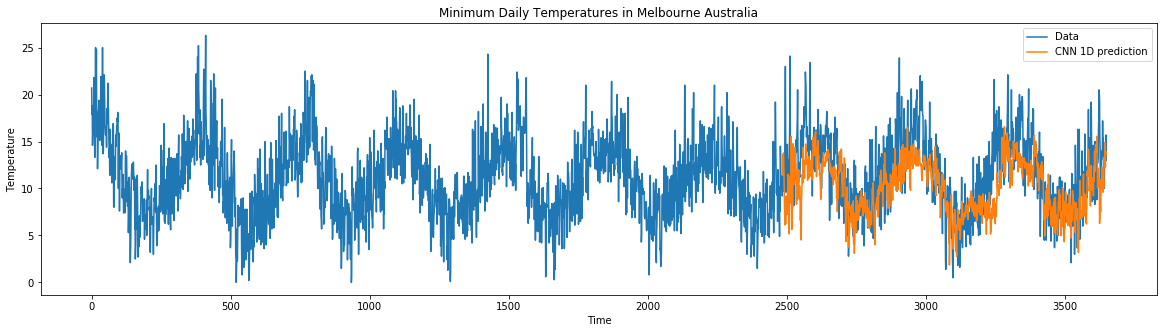

In [ ]:
plt.figure(figsize = [20,5])
plt.plot(data.Temp, label="Data")
plt.plot(range(len(train)+window+ndays, len(train) + len(test)), y_pred, label="CNN 1D prediction")
plt.title("Minimum Daily Temperatures in Melbourne Australia")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.show()